Data Processing

Dataset from Kaggle

In [ ]:
import os
import cv2

from google.colab import drive
drive.mount('/content/drive')

# Function to extract frames at 1 FPS
def extract_frames_from_video(video_path, output_folder, frame_rate=1):
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Failed to open video: {video_path}")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0:
        print(f"Invalid FPS for video: {video_path}")
        return

    frame_interval = int(fps / frame_rate)
    success, frame = cap.read()
    count = 0
    frame_id = 0

    while success:
        if count % frame_interval == 0:
            frame_filename = f"{video_name}_frame{frame_id}.jpg"
            save_path = os.path.join(output_folder, frame_filename)
            cv2.imwrite(save_path, frame)
            frame_id += 1
        success, frame = cap.read()
        count += 1

    cap.release()

# Defining folders and frame rate
base_path = "/content/drive/MyDrive/Driver Drowsiness Dataset"
datasets = ["YawDD", "SUSTDD"]
classes = ["Drowsy", "Not Drowsy"]  # Use space not underscore
output_base = "/content/drive/MyDrive/Extracted_Frames"
frame_rate = 1  # 1 frame per second

# Looping through all videos and extract frames
for dataset in datasets:
    for label in classes:
        input_folder = os.path.join(base_path, dataset, label)
        output_folder = os.path.join(output_base, dataset, label)

        os.makedirs(output_folder, exist_ok=True)

        video_files = [f for f in os.listdir(input_folder) if f.endswith((".avi", ".mp4"))]

        print(f"Processing {len(video_files)} videos in {input_folder}")

        for video in video_files:
            video_path = os.path.join(input_folder, video)
            extract_frames_from_video(video_path, output_folder, frame_rate)

print("✅ Frame extraction complete.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processing 110 videos in /content/drive/MyDrive/Driver Drowsiness Dataset/YawDD/Drowsy
Processing 146 videos in /content/drive/MyDrive/Driver Drowsiness Dataset/YawDD/Not Drowsy
Processing 975 videos in /content/drive/MyDrive/Driver Drowsiness Dataset/SUSTDD/Drowsy
Processing 1099 videos in /content/drive/MyDrive/Driver Drowsiness Dataset/SUSTDD/Not Drowsy
✅ Frame extraction complete.


Custom Dataset

In [ ]:
import cv2
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Set input and output paths
video_directory = "/content/drive/MyDrive/Driver Drowsiness Dataset/CustomDD/Drowsy"
output_directory = "/content/drive/MyDrive/Extracted_Frames/CustomDD/Drowsy"

# Create output directory if it doesn't exist
os.makedirs(output_directory, exist_ok=True)

# Supported video formats
video_extensions = ['.mp4', '.avi']

# Counter for frame filenames
frame_count = 0

# Process all video files
for filename in os.listdir(video_directory):
    if any(filename.lower().endswith(ext) for ext in video_extensions):
        video_path = os.path.join(video_directory, filename)
        cap = cv2.VideoCapture(video_path)

        if not cap.isOpened():
            print(f"Failed to open {filename}")
            continue

        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_interval = int(fps)  # Capture 1 frame per second

        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_idx % frame_interval == 0:
                frame_filename = f"frame_{frame_count:05d}.jpg"
                frame_path = os.path.join(output_directory, frame_filename)
                cv2.imwrite(frame_path, frame)
                frame_count += 1

            frame_idx += 1

        cap.release()
        print(f"Extracted frames from: {filename}")

print("✅ All frames extracted successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted frames from: WhatsApp Video 2025-07-04 at 14.33.10.mp4
Extracted frames from: WhatsApp Video 2025-07-04 at 14.52.09.mp4
Extracted frames from: WhatsApp Video 2025-07-04 at 14.52.09-2.mp4
Extracted frames from: WhatsApp Video 2025-07-04 at 14.52.09-3.mp4
Extracted frames from: WhatsApp Video 2025-07-06 at 15.29.25.mp4
Extracted frames from: WhatsApp Video 2025-07-06 at 15.29.26.mp4
Extracted frames from: fda6fabf-950e-4d20-86cc-c7ba2aa5052f.MP4
Extracted frames from: 5223eec6-cf32-4da1-ba3f-0c08f4325008.MP4
Extracted frames from: 72107d43-ac84-4214-8346-f53666b960e9.MP4
Extracted frames from: c669182c-9425-491a-8308-38ab537ab141.MP4
✅ All frames extracted successfully!


System Design and Implementation

In [ ]:
!pip install mediapipe opencv-python dlib imutils scikit-learn matplotlib
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install imutils


Istalling Libraries for feature extraction

In [ ]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2


--2025-08-06 19:53:51--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2025-08-06 19:53:53--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  17.2MB/s    in 4.3s    

2025-08-06 19:53:58 (14.4 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



In [ ]:
!bzip2 -dk shape_predictor_68_face_landmarks.dat.bz2


In [ ]:
import os
print("Files in current directory:", os.listdir())


Files in current directory: ['.config', 'shape_predictor_68_face_landmarks.dat', 'shape_predictor_68_face_landmarks.dat.bz2', 'drive', 'sample_data']


In [ ]:
predictor = dlib.shape_predictor("/content/shape_predictor_68_face_landmarks.dat")


Extracting EAR and MAR and running feature extraction on frames

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# STEP 1: IMPORT LIBRARIES
import os
import cv2
import dlib
import numpy as np
import pandas as pd
from imutils import face_utils
from tqdm.notebook import tqdm
from scipy.spatial import distance as dist

# STEP 2: DEFINE EAR, MAR & HEAD TILT FUNCTIONS
def compute_EAR(eye):
    A = dist.euclidean(eye[1], eye[5])
    B = dist.euclidean(eye[2], eye[4])
    C = dist.euclidean(eye[0], eye[3])
    ear = (A + B) / (2.0 * C)
    return ear

def compute_MAR(mouth):
    A = dist.euclidean(mouth[13], mouth[19])
    B = dist.euclidean(mouth[14], mouth[18])
    C = dist.euclidean(mouth[15], mouth[17])
    D = dist.euclidean(mouth[12], mouth[16])
    mar = (A + B + C) / (2.0 * D)
    return mar

def compute_head_tilt(shape):
    # Extract nose and eye landmarks
    nose_bridge = shape[27]  # Top of nose
    nose_bottom = shape[30]  # Bottom of nose
    left_eye = shape[36]     # Left eye corner
    right_eye = shape[45]    # Right eye corner

    # Calculate vertical nose vector
    nose_dy = nose_bottom[1] - nose_bridge[1]
    nose_dx = nose_bottom[0] - nose_bridge[0]

    # Calculate horizontal eye vector
    eyes_dy = right_eye[1] - left_eye[1]
    eyes_dx = right_eye[0] - left_eye[0]

    # Compute angles
    nose_angle = np.degrees(np.arctan2(nose_dy, nose_dx))
    eye_angle = np.degrees(np.arctan2(eyes_dy, eyes_dx))

    # Combine angles for robust tilt estimation
    head_tilt = (nose_angle + eye_angle) / 2.0
    return head_tilt

# STEP 3: INITIALIZE DLIB MODELS
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("/content/shape_predictor_68_face_landmarks.dat")

# STEP 4: SET PATHS
base_dir = "/content/drive/MyDrive/Extracted_Frames"
output_csv = "/content/driver_drowsiness_features_extended2.csv"

# STEP 5: PROCESS FRAMES AND EXTRACT FEATURES
data = []
EAR_THRESHOLD = 0.25  # Adjust based on your validation

for dataset in os.listdir(base_dir):
    dataset_path = os.path.join(base_dir, dataset)

    for class_label in os.listdir(dataset_path):
        label_path = os.path.join(dataset_path, class_label)
        label = 1 if class_label.lower() == "drowsy" else 0

        for img_name in tqdm(os.listdir(label_path), desc=f"{dataset}/{class_label}"):
            img_path = os.path.join(label_path, img_name)
            image = cv2.imread(img_path)

            if image is None:
                continue

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            faces = detector(gray, 0)

            for face in faces:
                shape = predictor(gray, face)
                shape = face_utils.shape_to_np(shape)

                # Extract regions
                left_eye = shape[42:48]
                right_eye = shape[36:42]
                mouth = shape[48:68]

                # Compute features
                ear_left = compute_EAR(left_eye)
                ear_right = compute_EAR(right_eye)
                ear = (ear_left + ear_right) / 2.0
                mar = compute_MAR(mouth)
                head_tilt = compute_head_tilt(shape)
                eye_state = 1 if ear < EAR_THRESHOLD else 0  # Blink state

                # Store features
                data.append([
                    ear_left,
                    ear_right,
                    ear,
                    mar,
                    head_tilt,
                    eye_state,
                    label
                ])
                break  # Process only first face

# STEP 6: SAVE TO CSV
columns = [
    "EAR_Left", "EAR_Right", "EAR_Avg",
    "MAR", "Head_Tilt", "Eye_State", "Label"
]
df = pd.DataFrame(data, columns=columns)
df.to_csv(output_csv, index=False)

print(f"✅ Extended features saved to {output_csv}")
print(f"Extracted {len(df)} samples")
df.head()

YawDD/Drowsy:   0%|          | 0/3761 [00:00<?, ?it/s]

YawDD/Not Drowsy:   0%|          | 0/3914 [00:00<?, ?it/s]

SUSTDD/Drowsy:   0%|          | 0/10152 [00:00<?, ?it/s]

SUSTDD/Not Drowsy:   0%|          | 0/11128 [00:00<?, ?it/s]

CustomDD/Drowsy:   0%|          | 0/238 [00:00<?, ?it/s]

✅ Extended features saved to /content/driver_drowsiness_features_extended2.csv
Extracted 25749 samples


,EAR_Left,EAR_Right,EAR_Avg,MAR,Head_Tilt,Eye_State,Label
0,0.254772,0.231403,0.243088,0.336344,38.274194,1,1
1,0.291343,0.263663,0.277503,0.045912,35.343145,0,1
2,0.350719,0.288897,0.319808,0.345173,32.115336,0,1
3,0.274563,0.229646,0.252104,0.051206,33.991772,0,1
4,0.338327,0.271632,0.304979,0.049229,33.955274,0,1


XGBoost classifier

In [ ]:
# STEP 1: Install libraries
!pip install xgboost scikit-learn pandas

# STEP 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# STEP 3: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import pickle

# STEP 4: Load the CSV file from Google Drive
csv_path = "/content/drive/MyDrive/driver_drowsiness_features_extended2.csv"
df = pd.read_csv(csv_path)
print(df.head())

# STEP 5: Select 6 features
features = ["EAR_Left", "EAR_Right", "EAR_Avg", "MAR", "Head_Tilt", "Eye_State"]
X = df[features]
y = df["Label"]

# STEP 6: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# STEP 7: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 8: Train XGBoost model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_scaled, y_train)

# STEP 9: Print accuracy
print(f" Accuracy: {model.score(X_test_scaled, y_test):.2f}")

# STEP 10: Save model and scaler to Google Drive
model_path = "/content/drive/MyDrive/best_drowsiness_model.pkl"
scaler_path = "/content/drive/MyDrive/standard_scaler.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model, f)

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

print(f" Files saved to Google Drive:\n- {model_path}\n- {scaler_path}")

Mounted at /content/drive
   EAR_Left  EAR_Right   EAR_Avg       MAR  Head_Tilt  Eye_State  Label
0  0.254772   0.231403  0.243088  0.336344  38.274194          1      1
1  0.291343   0.263663  0.277503  0.045912  35.343145          0      1
2  0.350719   0.288897  0.319808  0.345173  32.115336          0      1
3  0.274563   0.229646  0.252104  0.051206  33.991772          0      1
4  0.338327   0.271632  0.304979  0.049229  33.955274          0      1


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [17:43:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Accuracy: 0.61
✅ Files saved to Google Drive:
- /content/drive/MyDrive/best_drowsiness_model.pkl
- /content/drive/MyDrive/standard_scaler.pkl


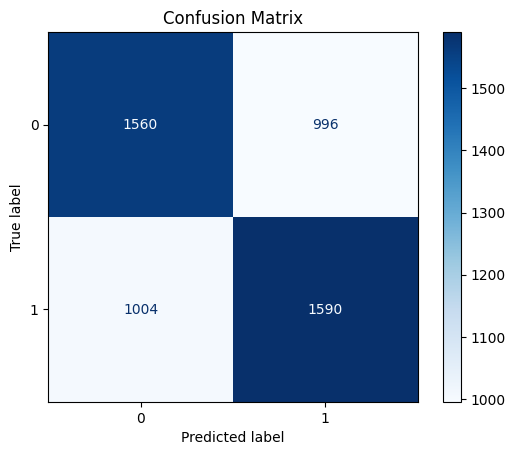

✅ Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.61      0.61      2556
           1       0.61      0.61      0.61      2594

    accuracy                           0.61      5150
   macro avg       0.61      0.61      0.61      5150
weighted avg       0.61      0.61      0.61      5150



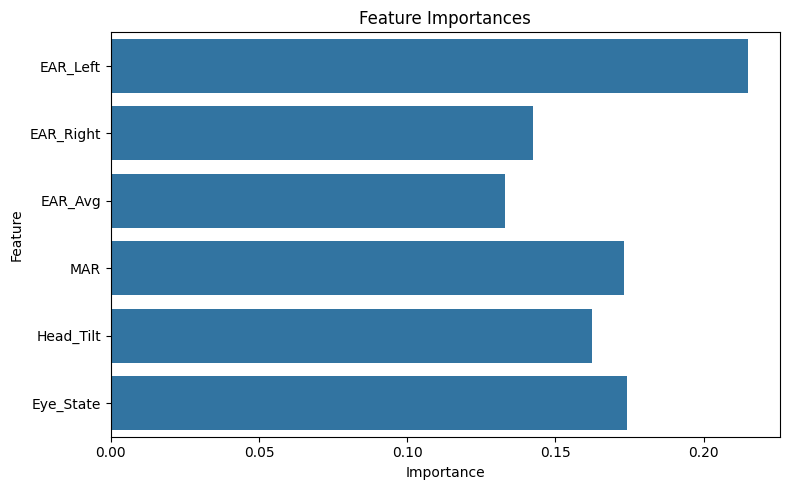

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

# ✅ 11.1: Confusion Matrix
y_pred = model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ✅ 11.2: Classification Report
print("✅ Classification Report:")
print(classification_report(y_test, y_pred))

# ✅ 11.3: Feature Importance Plot (XGBoost built-in)
importances = model.feature_importances_
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

# ✅ Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ✅ Save model to Drive
model_path = "/content/drive/MyDrive/best_drowsiness_model.pkl"
joblib.dump(model, model_path)

# ✅ Save scaler to Drive
scaler_path = "/content/drive/MyDrive/standard_scaler.pkl"
joblib.dump(scaler, scaler_path)

print("✅ Model and scaler saved to Google Drive.")

✅ Model and scaler saved to Google Drive.


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import joblib

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the same CSV you used for training
df = pd.read_csv('/content/drive/MyDrive/driver_drowsiness_features_extended2.csv')

# Select only the required 6 features
features = df[["EAR_Left", "EAR_Right", "EAR_Avg", "MAR", "Head_Tilt", "Eye_State"]]

# Fit the scaler
scaler = StandardScaler()
scaler.fit(features)

# Save it using joblib
joblib.dump(scaler, "/content/drive/MyDrive/standard_scaler.pkl")

print("✅ StandardScaler saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ StandardScaler saved to Google Drive!


In [ ]:
import pickle
from google.colab import drive

drive.mount('/content/drive')

# ✅ Save using pure pickle (not joblib or cloudpickle)
with open("/content/drive/MyDrive/standard_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Scaler saved as standard_scaler.pkl")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Scaler saved as standard_scaler.pkl


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive
